# Dani 800-baud beacon analysis — apples-for-apples 3-spacecraft comparison

This notebook keeps the same analysis sequence and equations as Dani's notebook, but runs the **same processing independently** on:

- USA-134
- USA-167
- WGS-6

Every plot-producing step is shown as **three side-by-side panels in the same figure**, one panel per spacecraft, with each spacecraft labeled.

No averaging of satellites together and no replacement plots.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

SATELLITES = {
    'USA-134': 'symbols_800baud_usa134.f32',
    'USA-167': 'symbols_800baud_usa167.f32',
    'WGS-6':   'symbols_800baud_wgs6.f32',
}


## Read symbols, determine 8-bit frame offset, and resolve BPSK polarity


In [2]:
D = {}

for sat, filename in SATELLITES.items():
    # Same 20,000-symbol skip as the supplied Dani/WGS notebook.
    x = np.fromfile(filename, dtype='float32')[20000:]

    offset_scores = []

    for test_off in range(8):
        usable = ((x.size - test_off) // 8) * 8
        test_z = x[test_off:test_off + usable].reshape((-1,8))
        offset_scores.append(abs(np.average(test_z[:,0])))

    off = int(np.argmax(offset_scores))
    usable = ((x.size - off) // 8) * 8
    z = x[off:off + usable].reshape((-1,8))

    # Same BPSK phase convention as Dani:
    # frame bit 0 must be the constant negative state.
    if np.average(z[:,0]) > 0:
        z = -z

    D[sat] = {
        'x': x,
        'z': z,
        'off': off,
        'offset_scores': offset_scores,
    }

    print('\n' + sat)
    print('offset scores =', offset_scores)
    print('off =', off)
    print('frame averages =', np.average(z, axis=0))



USA-134
offset scores = [0.12589827, 0.042952184, 0.043160934, 0.03549934, 0.001041818, 0.03716151, 0.084415674, 1.1551634]
off = 7
frame averages = [-1.1551627   0.12633194 -0.04351189  0.04262334  0.0349135  -0.00165521
 -0.03652967  0.08427715]

USA-167
offset scores = [0.00552357, 0.03474581, 0.03919325, 1.1624815, 0.125406, 0.0534809, 0.04141686, 0.039037827]
off = 3
frame averages = [-1.1624823   0.12540592 -0.05348091  0.04141691  0.03903782  0.00586974
 -0.03510278  0.03980875]

WGS-6
offset scores = [1.1425983, 0.11797198, 0.053819504, 0.040292636, 0.029491274, 0.0041927407, 0.037978627, 0.11899767]
off = 0
frame averages = [-1.1425974   0.11797214 -0.05416607  0.04075952  0.02914606  0.00448837
 -0.03766498  0.11919264]


## Dani plot 1 — Soft symbols


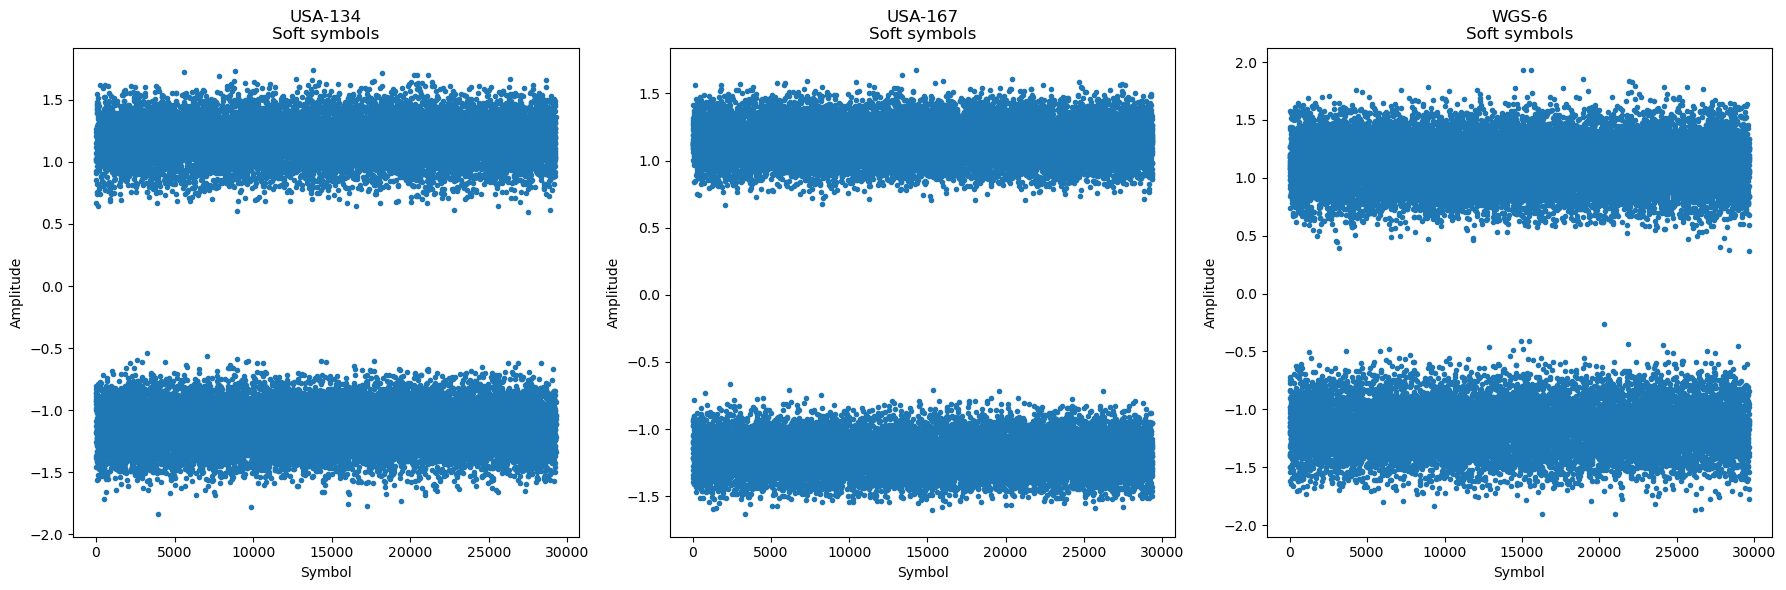

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18,6), facecolor='w')

for ax, (sat, d) in zip(axes, D.items()):
    ax.plot(d['x'], '.')
    ax.set_ylabel('Amplitude')
    ax.set_xlabel('Symbol')
    ax.set_title(f'{sat}\nSoft symbols')

plt.tight_layout()
plt.show()


## Dani plot 2 — Averages of each frame bit


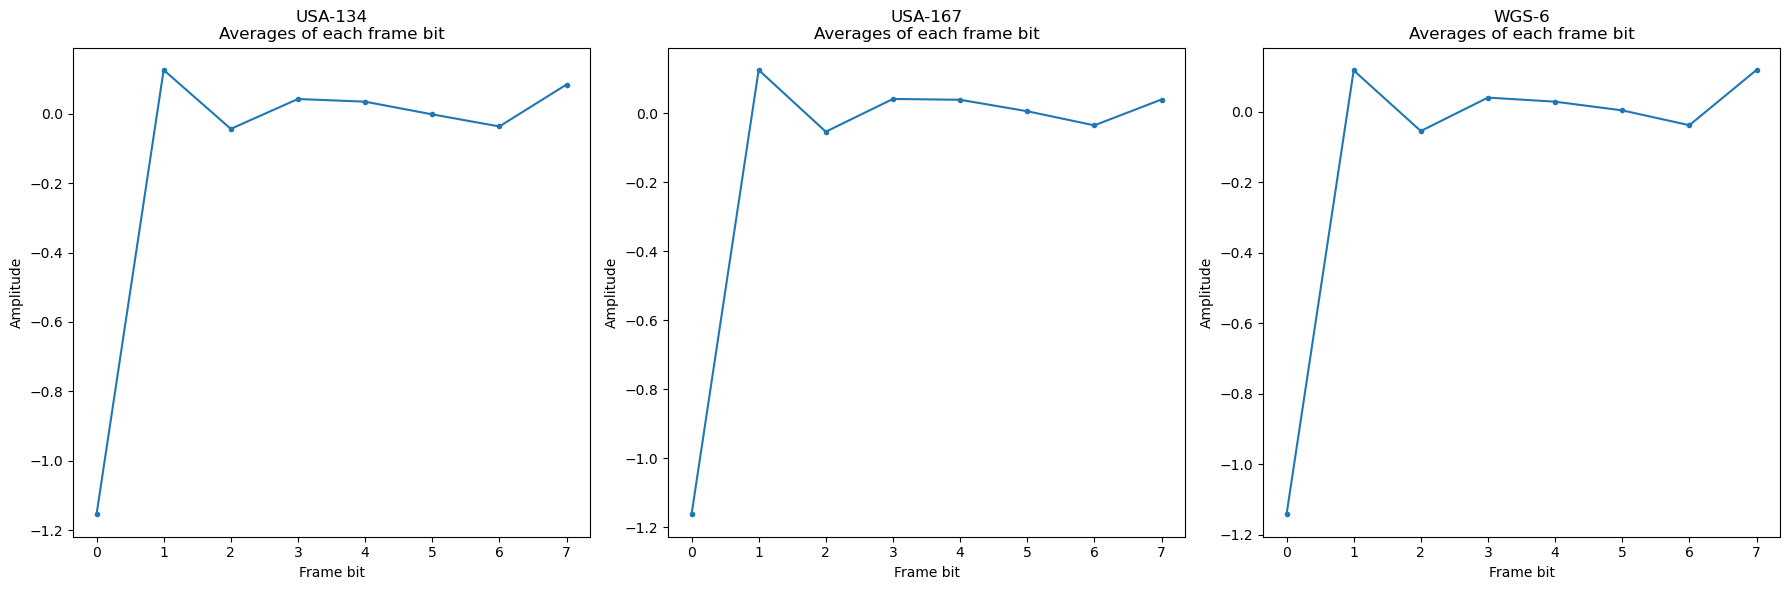

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18,6), facecolor='w')

for ax, (sat, d) in zip(axes, D.items()):
    ax.plot(np.average(d['z'], axis=0), '.-')
    ax.set_title(f'{sat}\nAverages of each frame bit')
    ax.set_ylabel('Amplitude')
    ax.set_xlabel('Frame bit')

plt.tight_layout()
plt.show()


## Dani plot 3 — Autocorrelation of each frame-bit sequence


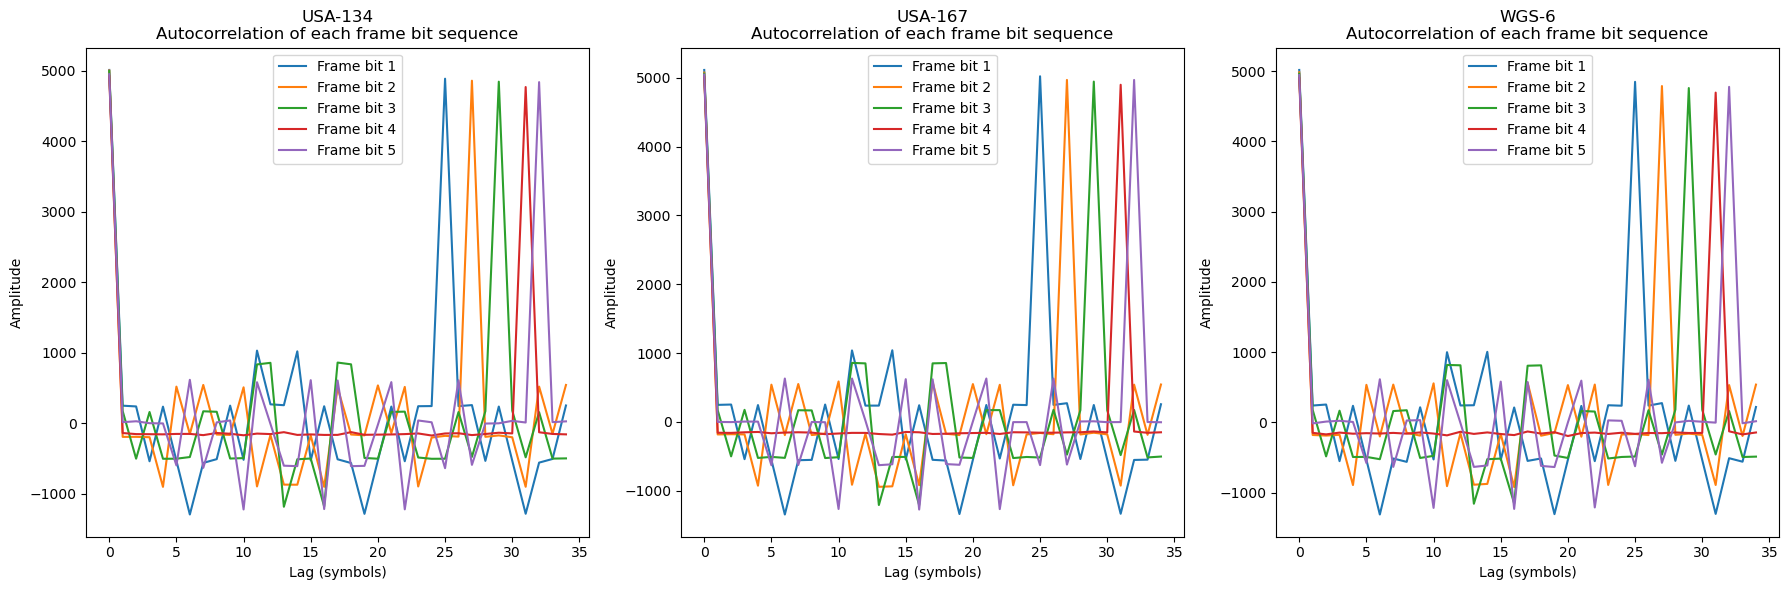

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18,6), facecolor='w')

for ax, (sat, d) in zip(axes, D.items()):
    z = d['z']

    for j in range(1,6):
        corr = scipy.signal.correlate(z[:,j], z[:,j], mode='full')
        ax.plot(corr[corr.size//2:][:35], label=f'Frame bit {j}')

    ax.set_title(f'{sat}\nAutocorrelation of each frame bit sequence')
    ax.set_ylabel('Amplitude')
    ax.set_xlabel('Lag (symbols)')
    ax.legend()

plt.tight_layout()
plt.show()


## Dani plot 4 — Frame bit 6 relation to frame bit 4


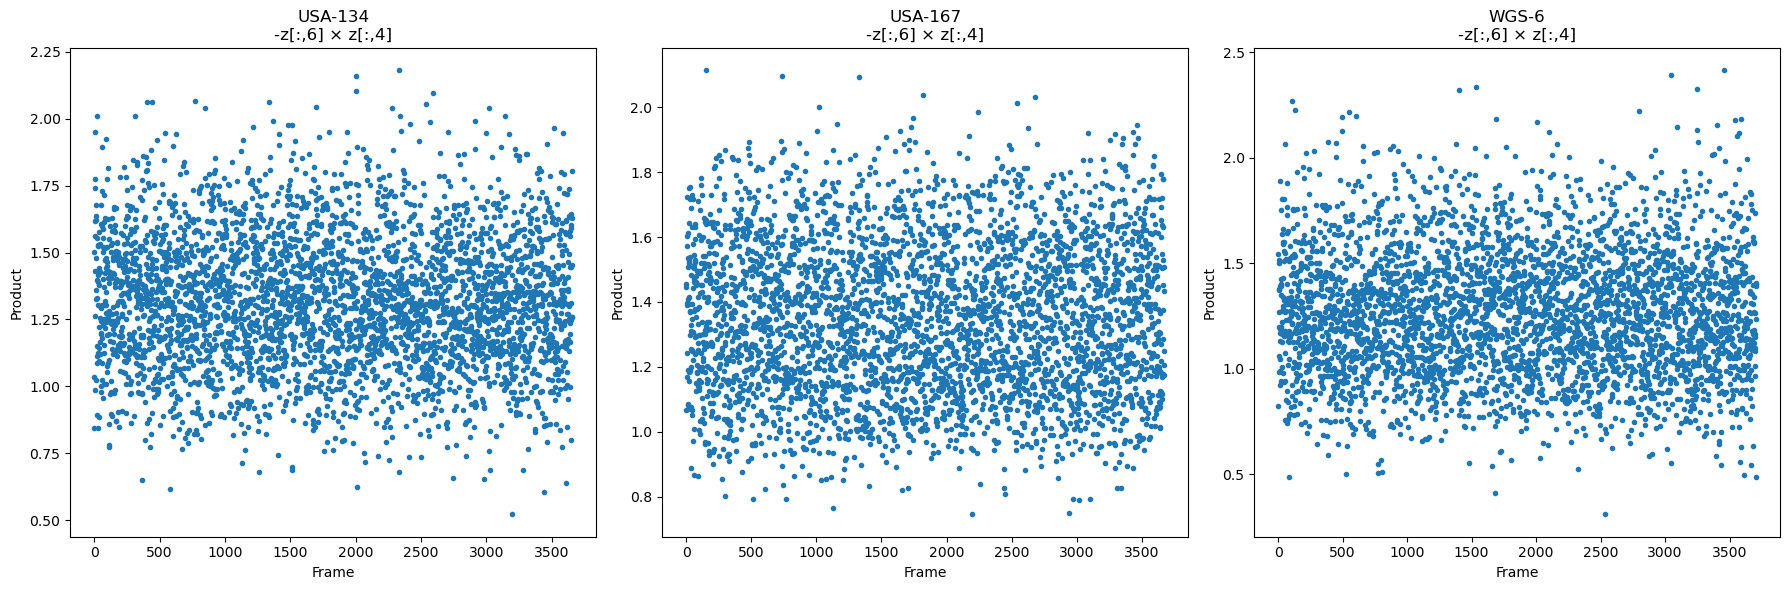

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,6), facecolor='w')

for ax, (sat, d) in zip(axes, D.items()):
    z = d['z']
    ax.plot(-z[:,6] * z[:,4], '.')
    ax.set_title(f'{sat}\n-z[:,6] × z[:,4]')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Product')

plt.tight_layout()
plt.show()


## Telemetry XOR-channel test — same channel 2 vs channel 3 comparison


In [7]:
def corr_score_200(v):
    v = v - np.average(v)
    corr = scipy.signal.correlate(v, v, mode='full')
    corr = corr[corr.size//2:]

    # Same Dani score, with only a zero-energy guard so the notebook
    # does not crash on a constant recovered stream.
    if corr[0] == 0:
        return np.nan

    corr = corr / corr[0]
    lags = [200, 400, 600, 800]
    return np.average([abs(corr[k]) for k in lags if k < corr.size])

for sat, d in D.items():
    z = d['z']

    b2 = -z[:,7] * z[:,2]
    b3 = -z[:,7] * z[:,3]

    score2 = corr_score_200(b2)
    score3 = corr_score_200(b3)

    if score3 > score2:
        b = b3
        telemetry_xor_channel = 3
    else:
        b = b2
        telemetry_xor_channel = 2

    d['b2'] = b2
    d['b3'] = b3
    d['b'] = b
    d['score2'] = score2
    d['score3'] = score3
    d['telemetry_xor_channel'] = telemetry_xor_channel

    print('\n' + sat)
    print('channel 2 score =', score2)
    print('channel 3 score =', score3)
    print('selected telemetry XOR channel =', telemetry_xor_channel)



USA-134
channel 2 score = 0.005432122
channel 3 score = 0.72554207
selected telemetry XOR channel = 3

USA-167
channel 2 score = 0.011658588
channel 3 score = 0.015209982
selected telemetry XOR channel = 3

WGS-6
channel 2 score = 0.008159681
channel 3 score = 0.015150555
selected telemetry XOR channel = 3


## Message synchronization — same five-one test


In [8]:
for sat, d in D.items():
    z = d['z']

    sync = np.where(
        np.convolve(
            np.all(np.sign(z[:,(1,5)]) == [1,1], axis=1),
            np.ones(5)
        ) == 5
    )[0]

    if sync.size == 0:
        raise RuntimeError(f'{sat}: No simultaneous 11111 run found in channels 1 and 5')

    framestart = int(sync[0])

    d['sync'] = sync
    d['framestart'] = framestart

    print('\n' + sat)
    print('sync candidates =', sync)
    print('framestart =', framestart)
    print('sync bits =')
    print(z[framestart-4:framestart+1,(1,5)])



USA-134
sync candidates = [ 564 1364 2164 2964]
framestart = 564
sync bits =
[[1.3115919 0.8503212]
 [1.2444553 1.1998532]
 [1.0758808 0.9622835]
 [1.0444952 1.5143027]
 [1.0266173 1.1473827]]

USA-167
sync candidates = [ 203 1003 1803 2603 3403]
framestart = 203
sync bits =
[[1.2089092 1.239466 ]
 [1.3649876 1.3093462]
 [1.2734543 1.1395583]
 [1.2474365 1.1713603]
 [1.4404684 1.037855 ]]

WGS-6
sync candidates = [ 130  930 1730 2530 3330]
framestart = 130
sync bits =
[[0.74259627 1.1207848 ]
 [1.2387329  1.2128183 ]
 [1.1181059  1.0214097 ]
 [0.89859855 1.0998783 ]
 [1.7290306  0.9996226 ]]


## Build 200-bit candidate words exactly as Dani does


In [9]:
for sat, d in D.items():
    b = d['b']
    framestart = d['framestart']

    bb = 1 * (b[framestart:] > 0)
    bb = bb[:bb.size//200*200].reshape((-1,200))

    d['bb'] = bb

    print(f"{sat}: {bb.shape[0]} complete 200-bit words")


USA-134: 15 complete 200-bit words
USA-167: 17 complete 200-bit words
WGS-6: 17 complete 200-bit words


## Dani plot 5 — Complete 200-bit words


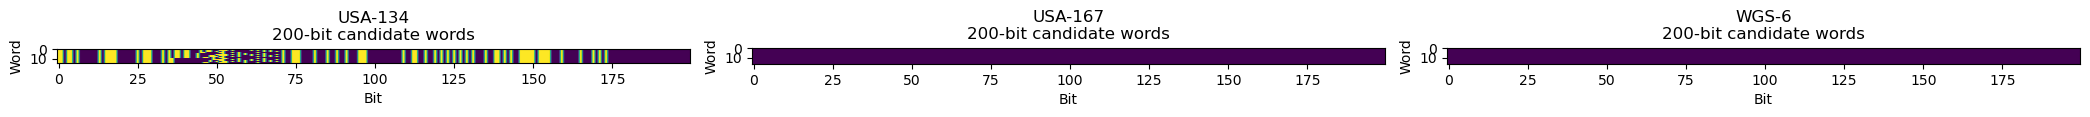

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(21,10))

for ax, (sat, d) in zip(axes, D.items()):
    ax.imshow(d['bb'], aspect=0.3)
    ax.set_title(f'{sat}\n200-bit candidate words')
    ax.set_xlabel('Bit')
    ax.set_ylabel('Word')

plt.tight_layout()
plt.show()


## Dani plot 6 — Even bits


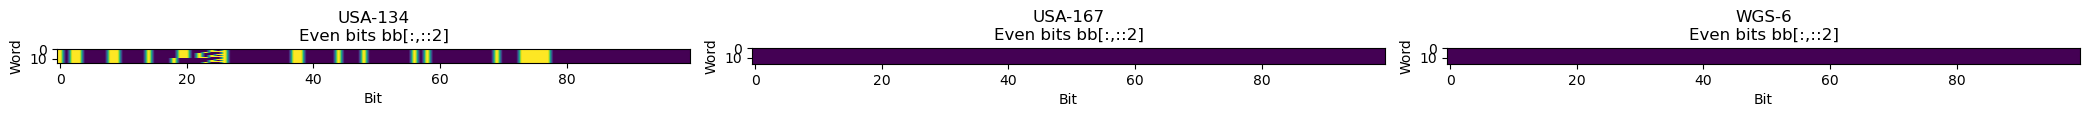

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(21,10))

for ax, (sat, d) in zip(axes, D.items()):
    ax.imshow(d['bb'][:,::2], aspect=0.15)
    ax.set_title(f'{sat}\nEven bits bb[:,::2]')
    ax.set_xlabel('Bit')
    ax.set_ylabel('Word')

plt.tight_layout()
plt.show()


## Dani plot 7 — Odd bits


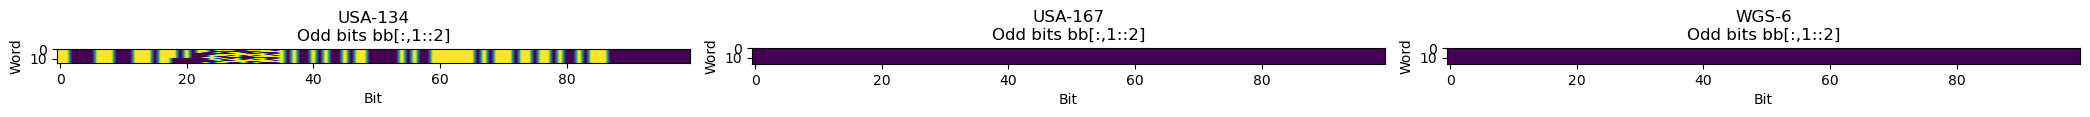

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(21,10))

for ax, (sat, d) in zip(axes, D.items()):
    ax.imshow(d['bb'][:,1::2], aspect=0.15)
    ax.set_title(f'{sat}\nOdd bits bb[:,1::2]')
    ax.set_xlabel('Bit')
    ax.set_ylabel('Word')

plt.tight_layout()
plt.show()


## Dani clock-field difference calculation


In [13]:
for sat, d in D.items():
    bb = d['bb']

    seconds = (np.packbits(bb[:,23*2:27*2:2], axis=1).ravel() >> 4).astype('int')
    ten_seconds = (np.packbits(bb[:,20*2:23*2:2], axis=1).ravel() >> 5).astype('int')
    minutes = (np.packbits(bb[:,16*2:20*2:2], axis=1).ravel() >> 4).astype('int')
    ten_minutes = (np.packbits(bb[:,13*2:16*2:2], axis=1).ravel() >> 5).astype('int')

    clock_diff = np.diff(seconds + 10*ten_seconds + 60*minutes + 600*ten_minutes)
    d['clock_diff'] = clock_diff

    print('\n' + sat)
    print(clock_diff)



USA-134
[2 2 2 2 2 2 2 2 2 2 2 2 2 2]

USA-167
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

WGS-6
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## Dani convolutional-code section — executed independently for each spacecraft


In [14]:
for sat, d in D.items():
    bb = d['bb']

    conv_input = bb[0,::2]
    conv_output = bb[0,1::2]

    d['conv_input'] = conv_input
    d['conv_output'] = conv_output

    print('\n' + sat)

    ii = np.where(conv_input)[0]
    oo = np.where(conv_output)[0]

    if ii.size and oo.size:
        print('last-output minus last-input index =', oo[-1] - ii[-1])
    else:
        print('last-output minus last-input index = undefined (all-zero/all-one candidate data)')



USA-134
last-output minus last-input index = 9

USA-167
last-output minus last-input index = 0

WGS-6
last-output minus last-input index = undefined (all-zero/all-one candidate data)


In [15]:
l = 10

for sat, d in D.items():
    conv_input = d['conv_input']
    conv_output = d['conv_output']

    A = np.zeros((10,10), dtype='int')
    rhs = np.zeros((10,1), dtype='int')

    for n,k in enumerate(range(7,17)):
        j = k - 10
        t = 0
        if j < 0:
            j = 0
            t = 10 - k
        A[n,t:] = conv_input[j:k]
        rhs[n] = conv_output[k-1]

    d['A'] = A
    d['rhs'] = rhs

    print('\n' + sat)

    try:
        p = np.linalg.solve(A, rhs).astype('int').ravel() % 2
        d['p'] = p
        print('p =', p)

        print(
            'first-word verification =',
            np.all(np.convolve(conv_input, p[::-1])[:conv_output.size] % 2 == conv_output)
        )

        bb = d['bb']
        print(
            'all-word verification =',
            np.all([
                np.all(
                    np.convolve(bb[j,::2], p[::-1])[:bb.shape[1]//2] % 2
                    == bb[j,1::2]
                )
                for j in range(bb.shape[0])
            ])
        )

    except np.linalg.LinAlgError as e:
        d['p'] = None
        print('generator solve unavailable:', e)



USA-134
p = [0 0 0 1 1 0 0 1 1 0]
first-word verification = False
all-word verification = False

USA-167
generator solve unavailable: Singular matrix

WGS-6
generator solve unavailable: Singular matrix


## What this notebook changes from Dani's original

Only the presentation/data handling is changed:

- the same analysis is run independently on all three `.f32` files;
- each original plot becomes one figure containing **three side-by-side spacecraft panels**;
- each panel is explicitly labeled **USA-134**, **USA-167**, or **WGS-6**;
- the convolutional solve has a guard so idle/degenerate data does not terminate the whole notebook.

The signal-processing comparisons themselves are not replaced by aggregate or invented metrics.
